**Author: Dhrubajyoti Ghosh**

**Capstone Project 1: Predictive Maintenance**

Version: 1.0

Date: 13 Jul 2026

--------------------------------------------

**Front End Link for Capstone Project 1:**

https://mlcap08preventivemaintenance-whacfj3ngvfpcxjoot6kvv.streamlit.app/

**Git Hub Link for Capstone Project 1:**

https://github.com/Dhruba041/ML_CAP_08_PREVENTIVE_MAINTENANCE

--------------------------------------
**Important:**

**Please Note: Project Report is uploaded in the shared GitHub Link**

--------------------------------------


In [4]:
#importing basic libraries

import pandas as pd
import numpy as np

import time
import math


In [5]:
#Importing the dataset
df = pd.read_csv('predictive_maintenance.csv')
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0


In [6]:
#Checking column Names
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target'],
      dtype='object')

In [7]:
#Renaming the columns

df = df.rename(columns={
    "UDI": "udi",
    "Product ID": "product_id",
    "Type": "type",
    "Air temperature [K]": "air_temperature",
    "Process temperature [K]": "process_temperature",
    "Rotational speed [rpm]": "rotational_speed",
    "Torque [Nm]": "torque",
    "Tool wear [min]": "tool_wear",
    "Target": "target"
})
df.head()

,udi,product_id,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [8]:
#Checking column Names after renaming
df.columns

Index(['udi', 'product_id', 'type', 'air_temperature', 'process_temperature',
       'rotational_speed', 'torque', 'tool_wear', 'target'],
      dtype='object')

In [9]:
#Generating summary about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   udi                  10000 non-null  int64  
 1   product_id           10000 non-null  object 
 2   type                 10000 non-null  object 
 3   air_temperature      10000 non-null  float64
 4   process_temperature  10000 non-null  float64
 5   rotational_speed     10000 non-null  int64  
 6   torque               10000 non-null  float64
 7   tool_wear            10000 non-null  int64  
 8   target               10000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 703.3+ KB


In [10]:
#Though from summary it can be seen there are no null records. Cross verifying the same.

df.isnull().sum().to_frame(name="null_count").reset_index().rename(columns={"index": "column_name"})

,column_name,null_count
0,udi,0
1,product_id,0
2,type,0
3,air_temperature,0
4,process_temperature,0
5,rotational_speed,0
6,torque,0
7,tool_wear,0
8,target,0


In [11]:
#Generating Descriptive Statistics. Transposing the columns for better visualization
df.describe().T

,count,mean,std,min,25%,50%,75%,max
udi,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
air_temperature,10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
process_temperature,10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
rotational_speed,10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
torque,10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
tool_wear,10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
target,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0


In [12]:
#checking for duplicate rows
int(df.duplicated().sum())

0

#code to drop the identified duplicate row:

df = df.drop_duplicates()

#missing % count

missing_percent_count = ((df.isnull().sum()/df.index.size)*100)

#not required as no duplicate found

In [13]:
#Checking value count of target column to see class imbalancing
df['target'].value_counts().reset_index(name='count')

,target,count
0,0,9661
1,1,339


In [14]:
#making a copy for the original dataset

df_org = df.copy()

In [15]:
#checking if udi is a sequence
df['udi'].nunique()

10000

In [16]:
#As number of unique values of udi = number of rows in the dataframe.
#Hence, it is a sequence and dropping the column.
df = df.drop(columns='udi')
df.head()

,product_id,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,target
0,M14860,M,298.1,308.6,1551,42.8,0,0
1,L47181,L,298.2,308.7,1408,46.3,3,0
2,L47182,L,298.1,308.5,1498,49.4,5,0
3,L47183,L,298.2,308.6,1433,39.5,7,0
4,L47184,L,298.2,308.7,1408,40.0,9,0


In [17]:
#checking if product_id is a sequence
df['product_id'].nunique()

10000

In [18]:
#Similarly dropping product id
df = df.drop(columns='product_id')
df.head()

,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,target
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [19]:
#Checking value count of type column to see the different classes
df['type'].value_counts().reset_index(name='count')

,type,count
0,L,6000
1,M,2997
2,H,1003


In [20]:
#Checking for class imbalance for combination of type and target

df[['type', 'target']].value_counts().reset_index(name='count')

,type,target,count
0,L,0,5765
1,M,0,2914
2,H,0,982
3,L,1,235
4,M,1,83
5,H,1,21


In [21]:
#primarily checking the correlation of dataframe numerical features
df.select_dtypes(include=np.number).corr()

,air_temperature,process_temperature,rotational_speed,torque,tool_wear,target
air_temperature,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
process_temperature,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
rotational_speed,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
torque,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
tool_wear,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
target,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


--------------------------
**Data Visualization**
--------------------------
--------------------------

In [127]:
#importing required libraries for data visualization
import seaborn as sns
import matplotlib.pyplot as plt

In [124]:
df_org.head()

,udi,product_id,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [125]:
df_org.columns

Index(['udi', 'product_id', 'type', 'air_temperature', 'process_temperature',
       'rotational_speed', 'torque', 'tool_wear', 'target'],
      dtype='object')

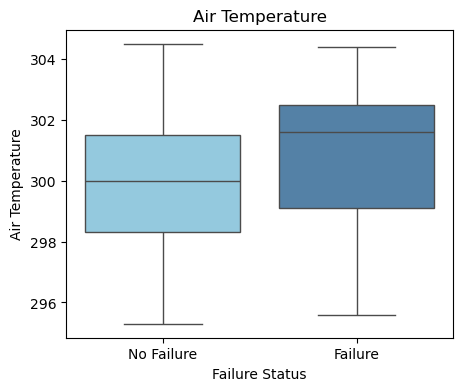

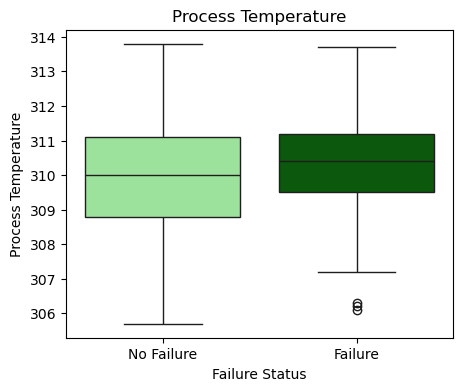

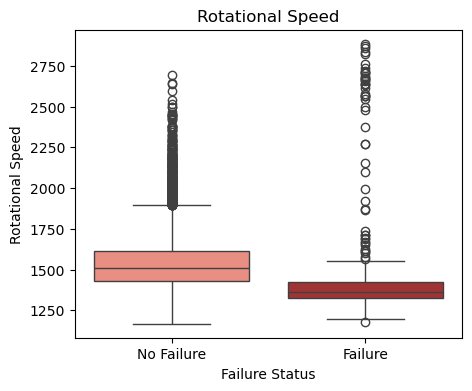

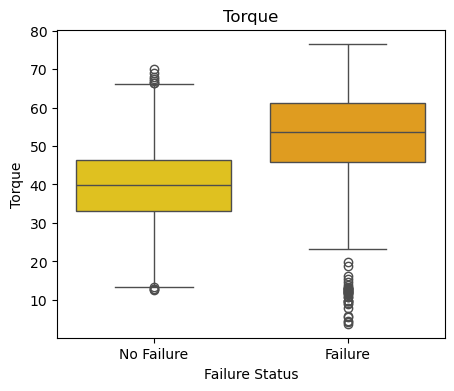

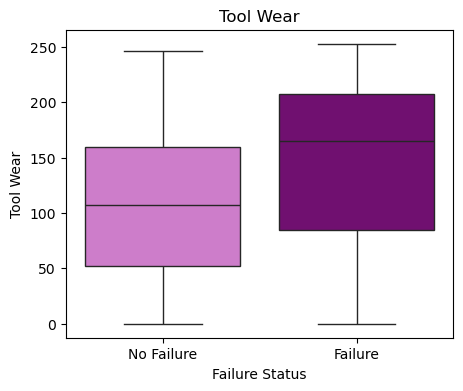

In [139]:
#Box Plot by Target

features = ['air_temperature',
            'process_temperature',
            'rotational_speed',
            'torque',
            'tool_wear']

palettes = [
    ['skyblue', 'steelblue'],
    ['lightgreen', 'darkgreen'],
    ['salmon', 'firebrick'],
    ['gold', 'orange'],
    ['orchid', 'purple']
]

for col, pal in zip(features, palettes):
    plt.figure(figsize=(5,4))

    sns.boxplot(
        data=df_org,
        x='target',
        y=col,
        hue='target',    
        palette=pal,
        legend=False       
    )

    plt.xticks([0, 1], ['No Failure', 'Failure'])
    plt.title(col.replace('_', ' ').title())
    plt.xlabel("Failure Status")
    plt.ylabel(col.replace('_', ' ').title())
    plt.show()

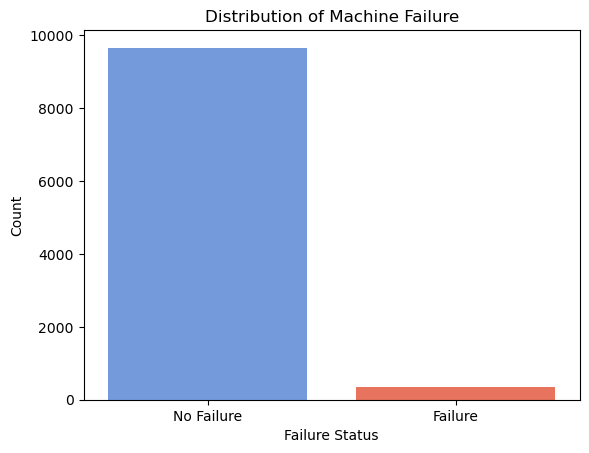

In [140]:
#Machine Failure Distribution
sns.countplot(
    data=df_org,
    x='target',
    hue='target',
    palette=['cornflowerblue', 'tomato'],
    legend=False
)

plt.title("Distribution of Machine Failure")
plt.xticks([0, 1], ['No Failure', 'Failure'])
plt.xlabel("Failure Status")
plt.ylabel("Count")
plt.show()

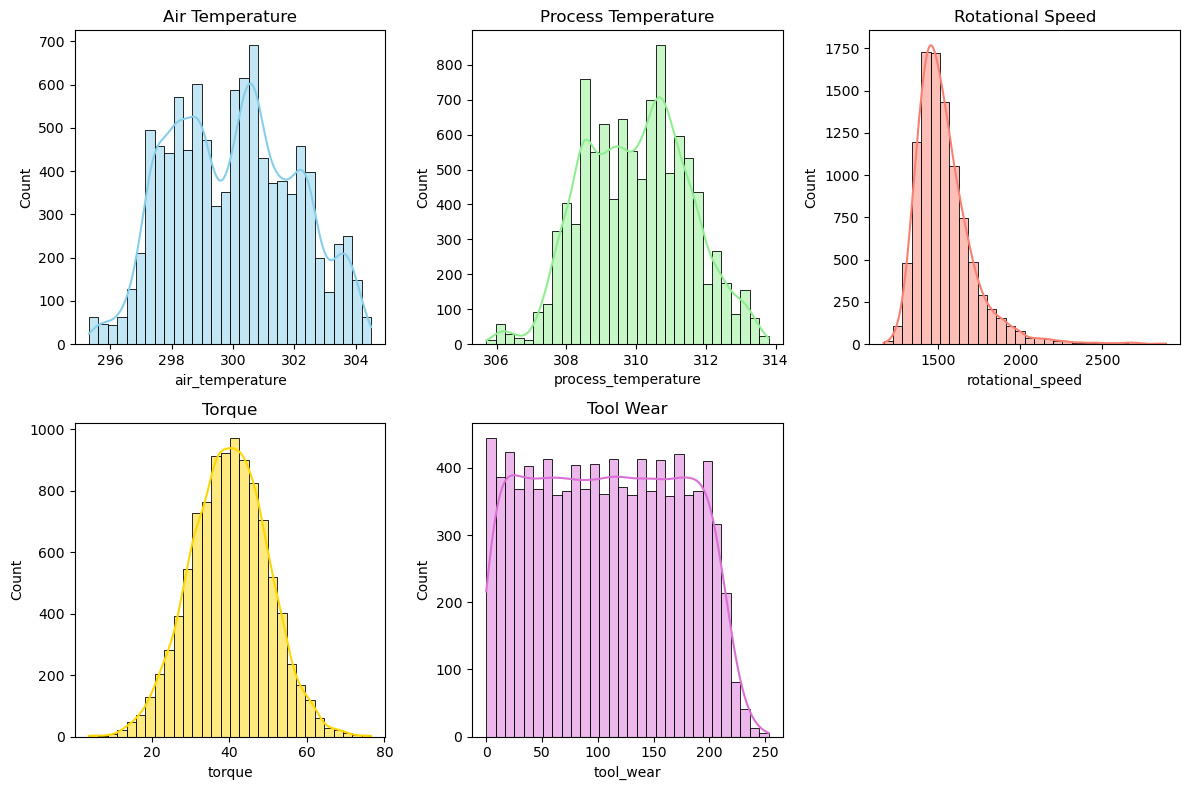

In [142]:
#Checking distribution of Variables with KDE

features = ['air_temperature',
            'process_temperature',
            'rotational_speed',
            'torque',
            'tool_wear']

colors = ['skyblue', 'lightgreen', 'salmon', 'gold', 'orchid']

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, col, color in zip(axes, features, colors):
    sns.histplot(df_org[col], kde=True, color=color, bins=30, ax=ax)
    ax.set_title(col.replace('_', ' ').title())

fig.delaxes(axes[-1])  # remove empty plot
plt.tight_layout()
plt.show()


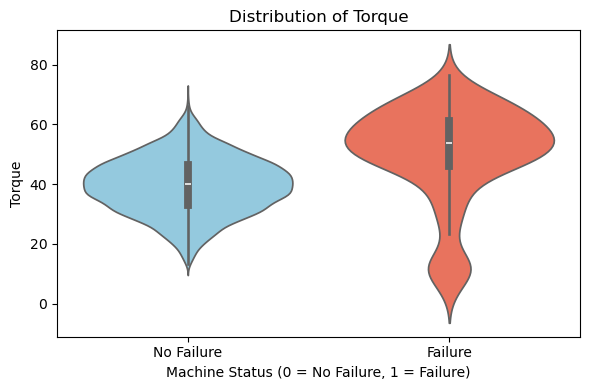

In [144]:
#Distibution of Features
plt.figure(figsize=(6,4))

sns.violinplot(
    data=df_org,
    x='target',
    y='torque',
    hue='target',
    palette=['skyblue', 'tomato'],
    legend=False
)

plt.title("Distribution of Torque")
plt.xlabel("Machine Status (0 = No Failure, 1 = Failure)")
plt.ylabel("Torque")

plt.xticks([0, 1], ['No Failure', 'Failure'])

plt.tight_layout()
plt.show()

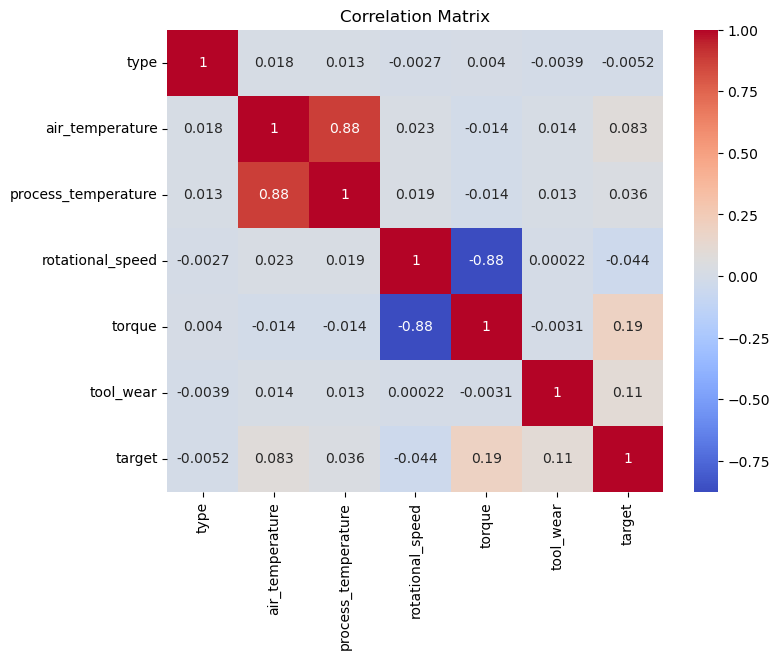

In [145]:
#plotting Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

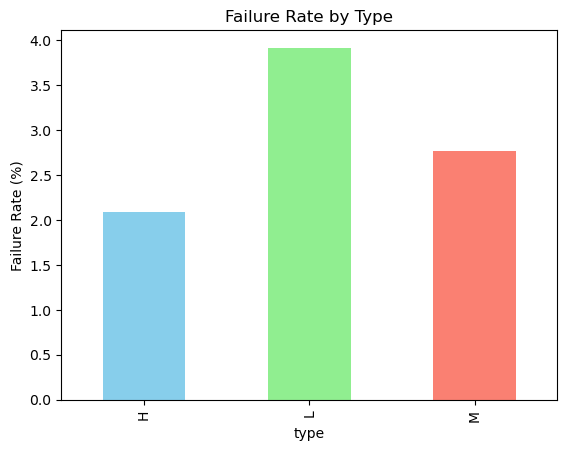

In [149]:
#Failure % by Machine Type

failure_rate = df_org.groupby('type')['target'].mean() * 100

failure_rate.plot(
    kind='bar',
    color=['skyblue', 'lightgreen', 'salmon']
)

plt.ylabel("Failure Rate (%)")
plt.title("Failure Rate by Type")
plt.show()

<Figure size 600x400 with 0 Axes>

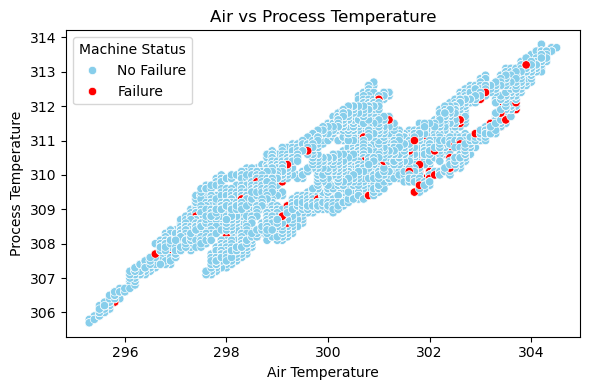

In [158]:
#Air Temperature vs Process Temperature
plt.figure(figsize=(6,4))
df_plot = df_org.copy()
df_plot['target'] = df_plot['target'].map({0: 'No Failure', 1: 'Failure'})

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df_plot,
    x='air_temperature',
    y='process_temperature',
    hue='target',
    palette={'No Failure': 'skyblue', 'Failure': 'red'}
)

plt.title("Air vs Process Temperature")
plt.xlabel("Air Temperature")
plt.ylabel("Process Temperature")

plt.legend(title="Machine Status")

plt.tight_layout()
plt.show()

--------------------------
**Identifying best ML model and **
--------------------------
--------------------------

In [22]:
#label encoding type column
from sklearn.preprocessing import LabelEncoder

le_type = LabelEncoder()
df = df.copy()
df['type'] = le_type.fit_transform(df['type'])

In [23]:
#checking the values
df.head(10)

,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,target
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0
5,2,298.1,308.6,1425,41.9,11,0
6,1,298.1,308.6,1558,42.4,14,0
7,1,298.1,308.6,1527,40.2,16,0
8,2,298.3,308.7,1667,28.6,18,0
9,2,298.5,309.0,1741,28.0,21,0


In [24]:
df[['type', 'target']].value_counts().reset_index(name='count')

,type,target,count
0,1,0,5765
1,2,0,2914
2,0,0,982
3,1,1,235
4,2,1,83
5,0,1,21


In [25]:
#primarily checking the correlation of dataframe features
df.select_dtypes(include=np.number).corr()

,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,target
type,1.000000,0.017599,0.013444,-0.002693,0.004011,-0.003930,-0.005152
air_temperature,0.017599,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
process_temperature,0.013444,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
rotational_speed,-0.002693,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
torque,0.004011,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
tool_wear,-0.003930,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
target,-0.005152,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


In [26]:
#Function to calculate VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(input_df):
    vif_df = pd.DataFrame()
    vif_df["Feature"] = input_df.columns
    vif_df["VIF"] = [
        variance_inflation_factor(input_df.values, i)
        for i in range(input_df.shape[1]) 
    ]
    return vif_df

In [27]:
#Calculating VIF
df_vif = df.drop(columns=['target']) 
vif_values = calculate_vif(df_vif) 
vif_values

,Feature,VIF
0,type,4.995157
1,air_temperature,87427.377972
2,process_temperature,88288.552894
3,rotational_speed,315.330345
4,torque,72.125897
5,tool_wear,3.877310


Due to high correlation between air_temperature and process_temperature, initially I was planning to remove air_temperature.
However, both the fields are critical factors in determining the chances of failure. Also, type column being categorical in nature may distort VIF calculation. Hence, I am moving forward with both the features.

In [28]:
df.head()

,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,target
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0


In [29]:
#Creating a function to check positive and negative skewness
def check_skew_dirn(val):
    if val > 0:
        return "Positive/Right"
    elif val < 0:
        return "Negative/Left"
    else:
        return "No Skew"

In [30]:
#Creating a function to categorize columns as per skewness

def categorize_skew(val):
    abs_skew = abs(val)
    
    if abs_skew < 0.5:
        lvl = "Lightly skewed"
    elif abs_skew < 1:
        lvl = "Moderately skewed"
    else:
        lvl = "Highly skewed"
    
    return lvl

In [31]:
#Perfroming x/y split
#Independent Variables
x = df.drop(["target"], axis = 1)
#Dependent Variable
y = df["target"]

In [32]:
#Checking Independent Variables
x.head()

,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear
0,2,298.1,308.6,1551,42.8,0
1,1,298.2,308.7,1408,46.3,3
2,1,298.1,308.5,1498,49.4,5
3,1,298.2,308.6,1433,39.5,7
4,1,298.2,308.7,1408,40.0,9


In [33]:
#Checking Dependent Variables
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [34]:
#Perfroming train test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 3, stratify = y)

In [35]:
#Handling Class Imbalance - Using SMOTE TOMEK
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(random_state=3)
x_train_smote, y_train_smote = smote_tomek.fit_resample(x_train, y_train)

In [36]:
#Checking
x_train_smote.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14376 entries, 0 to 14375
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 14376 non-null  int64  
 1   air_temperature      14376 non-null  float64
 2   process_temperature  14376 non-null  float64
 3   rotational_speed     14376 non-null  int64  
 4   torque               14376 non-null  float64
 5   tool_wear            14376 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 674.0 KB


In [37]:
#Checking
y_train_smote.info()

<class 'pandas.core.series.Series'>
RangeIndex: 14376 entries, 0 to 14375
Series name: target
Non-Null Count  Dtype
--------------  -----
14376 non-null  int64
dtypes: int64(1)
memory usage: 112.4 KB


In [38]:
#Checking Skewness
df_skewness = x_train_smote.skew().to_frame(name="skewness").reset_index().rename(columns={"index": "column_name"})
df_skewness

,column_name,skewness
0,type,0.074650
1,air_temperature,-0.205438
2,process_temperature,-0.189680
3,rotational_speed,2.722175
4,torque,-0.497204
5,tool_wear,-0.169387


In [39]:
#Checking skewness of the columns

df_skewness_cpy = df_skewness.copy()
df_skewness_cpy["skew_category"] = df_skewness_cpy["skewness"].apply(categorize_skew)
df_skewness_cpy

,column_name,skewness,skew_category
0,type,0.074650,Lightly skewed
1,air_temperature,-0.205438,Lightly skewed
2,process_temperature,-0.189680,Lightly skewed
3,rotational_speed,2.722175,Highly skewed
4,torque,-0.497204,Lightly skewed
5,tool_wear,-0.169387,Lightly skewed


In [40]:
#Identifying highly and moderately skewed columns and converting it into a list
skewed_cols = df_skewness_cpy[
    df_skewness_cpy["skew_category"].isin([
        "Highly skewed",
        "Moderately skewed"
    ])
]["column_name"].tolist()
skewed_cols

['rotational_speed']

In [41]:
#As Label Encoding Already Done to Encode Type Column and Target is already Numerical
#Hence, Proceeding towards Power Transformer to remove skewness
from sklearn.preprocessing import PowerTransformer
x_test_smote = x_test.copy()
pt = PowerTransformer(method="yeo-johnson")
x_train_smote[skewed_cols] = pt.fit_transform(x_train_smote[skewed_cols]) #for power transform
x_test_smote[skewed_cols] = pt.transform(x_test_smote[skewed_cols])

In [42]:
#Handling Outliers using Capping & Flooring method

def manage_outliers(col_df, col_name):
    lower = col_df[col_name].quantile(0.01)
    upper = col_df[col_name].quantile(0.99)
    col_df[col_name] = col_df[col_name].clip(lower,upper)
    return col_df

In [45]:
#Treating Outliers for Training Dataset
#Note: Outliers should be handled in training dataset only
for col in x_train_smote.columns:
    x_smote = manage_outliers(x_train_smote, col)

In [46]:
#Since co categorical record present to not encoding categorical value
#Progressing towards Scaling using MinMax Scaler as all are numerical fields
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
x_smote_train_scaled = scaler.fit_transform(x_smote)
x_smote_test_scaled = scaler.transform(x_test_smote)

In [47]:
x_smote.columns

Index(['type', 'air_temperature', 'process_temperature', 'rotational_speed',
       'torque', 'tool_wear'],
      dtype='object')

In [48]:
x_smote_train_scaled.shape

(14376, 6)

In [49]:
x_smote_test_scaled.shape

(2500, 6)

---------------------------------------------
**ML Model Evaluation**

---------------------------------------------

In [50]:
#importing libraries for ML Classification Models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV

In [51]:
#Defining the models for evaluation

models_classifier = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=3),
    "Random Forest": RandomForestClassifier(random_state=3),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(random_state=3),
    "Bagging": BaggingClassifier(random_state=3),
    "Gradient Boosting": GradientBoostingClassifier(random_state=3), #Rejected due to very high time consumption. Also, other models accuracy are above 90%
    "XGBoost": XGBClassifier(random_state=3, eval_metric="logloss")
}

In [52]:
#Using Stratified K-Fold Cross Validation
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)

In [53]:
#Cross validating the performance of various models

def print_model_classifier_scores(model, model_name,  x_training, y_training):
    scores = cross_val_score(model, x_training, y_training, cv=skf, scoring='accuracy')
    print(f"Model Name: {model_name} | Score: {np.mean(scores):.4f}")

In [57]:
#Question c: Defining the classifier models for cross validation

print("******CV Scores**************************")
for name, model in models_classifier.items():
    print_model_classifier_scores(model, name, x_smote_train_scaled, y_train_smote)
print("********************************")

******CV Scores**************************
Model Name: Logistic Regression | Score: 0.7745
Model Name: Decision Tree | Score: 0.9678
Model Name: Random Forest | Score: 0.9775
Model Name: KNN | Score: 0.9537
Model Name: SVM | Score: 0.9415
Model Name: Naive Bayes | Score: 0.8394
Model Name: AdaBoost | Score: 0.9034
Model Name: Bagging | Score: 0.9730
Model Name: Gradient Boosting | Score: 0.9513
Model Name: XGBoost | Score: 0.9825
********************************


In [58]:
#Defining a function that takes predicted value and actual value as input and Classification Metrics Values

def classification_metrics_all(
    y_train_actual, y_train_predicted,
    y_test_actual, y_test_predicted,
    overfit_threshold
):

    # Accuracy
    train_acc = accuracy_score(y_train_actual, y_train_predicted)
    test_acc = accuracy_score(y_test_actual, y_test_predicted)

    # Precision (per class)
    train_precision = precision_score(y_train_actual, y_train_predicted, average=None, zero_division=0)
    test_precision = precision_score(y_test_actual, y_test_predicted, average=None, zero_division=0)

    # Recall (per class)
    train_recall = recall_score(y_train_actual, y_train_predicted, average=None, zero_division=0)
    test_recall = recall_score(y_test_actual, y_test_predicted, average=None, zero_division=0)

    # F1-score (per class)
    train_f1 = f1_score(y_train_actual, y_train_predicted, average=None, zero_division=0)
    test_f1 = f1_score(y_test_actual, y_test_predicted, average=None, zero_division=0)

    # Confusion Matrix
    train_cm = confusion_matrix(y_train_actual, y_train_predicted)
    test_cm = confusion_matrix(y_test_actual, y_test_predicted)

    # Overfitting check (based on accuracy gap)
    if (train_acc - test_acc) > overfit_threshold:
        overfit_flag = 'Y'
    else:
        overfit_flag = 'N'

    return (
        train_acc, test_acc,
        train_precision, test_precision,
        train_recall, test_recall,
        train_f1, test_f1,
        train_cm, test_cm,
        overfit_flag
    )


In [59]:
#Defining a function that takes the training and testing dataset and model name as input and returns the model performance metrics


def evaluate_classification_model(
    model, model_name,
    x_training, y_training,
    x_testing, y_testing,
    overfit_threshold=0.05
):

    # training the model
    model.fit(x_training, y_training)

    # predictions
    y_train_pred = model.predict(x_training)
    y_test_pred = model.predict(x_testing)

    # calling classification_metrics_all function
    (
        train_acc, test_acc,
        train_precision, test_precision,
        train_recall, test_recall,
        train_f1, test_f1,
        train_cm, test_cm,
        overfit_flag
    ) = classification_metrics_all(
        y_training, y_train_pred,
        y_testing, y_test_pred,
        overfit_threshold
    )

    return {
        "Model Name": model_name,

        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),

        "Train Precision (per class)": train_precision,
        "Test Precision (per class)": test_precision,

        "Train Recall (per class)": train_recall,
        "Test Recall (per class)": test_recall,

        "Train F1-score (per class)": train_f1,
        "Test F1-score (per class)": test_f1,

        "Train Confusion Matrix": train_cm,
        "Test Confusion Matrix": test_cm,

        "Overfitting (Y/N)": overfit_flag
    }

In [61]:
#comparing the models:

evaluation_results_smote = []

for name, model in models_classifier.items():
    print("Processing Model:", name)

    evaluation_results_smote.append(
        evaluate_classification_model(
            model,
            name,
            x_smote_train_scaled, 
            y_train_smote,
            x_smote_test_scaled,
            y_test
        )
    )


Processing Model: Logistic Regression
Processing Model: Decision Tree
Processing Model: Random Forest
Processing Model: KNN
Processing Model: SVM
Processing Model: Naive Bayes
Processing Model: AdaBoost
Processing Model: Bagging
Processing Model: Gradient Boosting
Processing Model: XGBoost


In [62]:
# convert result to DataFrame
perfromance_df_smote = pd.DataFrame(evaluation_results_smote)

In [63]:
perfromance_df_smote

,Model Name,Train Accuracy,Test Accuracy,Train Precision (per class),Test Precision (per class),Train Recall (per class),Test Recall (per class),Train F1-score (per class),Test F1-score (per class),Train Confusion Matrix,Test Confusion Matrix,Overfitting (Y/N)
0,Logistic Regression,0.7753,0.7744,"[0.7853742968411943, 0.7658202337767029]","[0.9894235854045479, 0.10673234811165845]","[0.7575125208681135, 0.7929883138564274]","[0.7747412008281573, 0.7647058823529411]","[0.7711918419375399, 0.7791675210170187]","[0.869019972131909, 0.1873198847262248]","[[5445, 1743], [1488, 5700]]","[[1871, 544], [20, 65]]",N
1,Decision Tree,1.0000,0.9576,"[1.0, 1.0]","[0.9923240938166311, 0.432258064516129]","[1.0, 1.0]","[0.9635610766045548, 0.788235294117647]","[1.0, 1.0]","[0.9777310924369748, 0.5583333333333333]","[[7188, 0], [0, 7188]]","[[2327, 88], [18, 67]]",N
2,Random Forest,0.9999,0.9608,"[0.9998608985950758, 1.0]","[0.9910979228486647, 0.45390070921985815]","[1.0, 0.9998608792431831]","[0.9681159420289855, 0.7529411764705882]","[0.9999304444599012, 0.9999304347826087]","[0.9794721407624634, 0.5663716814159292]","[[7188, 0], [1, 7187]]","[[2338, 77], [21, 64]]",N
3,KNN,0.9706,0.9252,"[0.9951690821256038, 0.94831013916501]","[0.9916151809355693, 0.28205128205128205]","[0.9457429048414023, 0.9954090150250418]","[0.9304347826086956, 0.7764705882352941]","[0.9698266638133961, 0.9712889431887599]","[0.9600512710959197, 0.41379310344827586]","[[6798, 390], [33, 7155]]","[[2247, 168], [19, 66]]",N
4,SVM,0.9439,0.9128,"[0.9681631455399061, 0.9220899470899471]","[0.995489400090212, 0.26501766784452296]","[0.9180578742348359, 0.969810795770729]","[0.913871635610766, 0.8823529411764706]","[0.9424450157097972, 0.945348521833469]","[0.9529360967184801, 0.4076086956521739]","[[6599, 589], [217, 6971]]","[[2207, 208], [10, 75]]",N
5,Naive Bayes,0.8405,0.8328,"[0.8556895800029065, 0.8265510340226818]","[0.9940623453735774, 0.1524008350730689]","[0.8191430161380078, 0.8618530884808013]","[0.8318840579710145, 0.8588235294117647]","[0.8370175563295188, 0.8438330041544644]","[0.9057709648331831, 0.25886524822695034]","[[5888, 1300], [993, 6195]]","[[2009, 406], [12, 73]]",N
6,AdaBoost,0.9078,0.9016,"[0.9200343938091143, 0.8961881589618816]","[0.9945280437756497, 0.23778501628664495]","[0.8931552587646077, 0.9223706176961602]","[0.9031055900621118, 0.8588235294117647]","[0.9063955950868277, 0.9090909090909091]","[0.9466145833333334, 0.37244897959183676]","[[6420, 768], [558, 6630]]","[[2181, 234], [12, 73]]",N
7,Bagging,0.9983,0.9596,"[0.998330550918197, 0.998330550918197]","[0.9906700593723494, 0.44366197183098594]","[0.998330550918197, 0.998330550918197]","[0.967287784679089, 0.7411764705882353]","[0.998330550918197, 0.998330550918197]","[0.9788393044206998, 0.5550660792951542]","[[7176, 12], [12, 7176]]","[[2336, 79], [22, 63]]",N
8,Gradient Boosting,0.9568,0.9376,"[0.9702133753401117, 0.9441363451913972]","[0.9938784433756013, 0.3333333333333333]","[0.9425431274346132, 0.9710628825820813]","[0.9412008281573498, 0.8352941176470589]","[0.9561781102251076, 0.9574103285097044]","[0.9668226286686517, 0.47651006711409394]","[[6775, 413], [208, 6980]]","[[2273, 142], [14, 71]]",N
9,XGBoost,0.9995,0.9648,"[1.0, 0.9990271021542738]","[0.993217465027554, 0.48936170212765956]","[0.9990261547022816, 1.0]","[0.9701863354037267, 0.8117647058823529]","[0.9995128401419723, 0.9995133143294167]","[0.9815668202764977, 0.6106194690265486]","[[7181, 7], [0, 7188]]","[[2343, 72], [16, 69]]",N


------------------------------------------------------------------------
Checking Performance on Original Dataset

------------------------------------------------------------------------

In [64]:
#Making copy of trainning and testing dataset. Not copying o/p dataset as no transformation will be implemented on it

x_train_org = x_train.copy()
x_test_org = x_test.copy()

In [65]:
#Checking Skewness
df_skewness_org = x_train_org.skew().to_frame(name="skewness").reset_index().rename(columns={"index": "column_name"})
df_skewness_org

,column_name,skewness
0,type,-0.101647
1,air_temperature,0.109888
2,process_temperature,0.012467
3,rotational_speed,2.045220
4,torque,-0.019949
5,tool_wear,0.021937


In [66]:
#Checking skewness of the columns

df_skewness_cpy_org = df_skewness_org.copy()
df_skewness_cpy_org["skew_category"] = df_skewness_cpy_org["skewness"].apply(categorize_skew)
df_skewness_cpy_org

,column_name,skewness,skew_category
0,type,-0.101647,Lightly skewed
1,air_temperature,0.109888,Lightly skewed
2,process_temperature,0.012467,Lightly skewed
3,rotational_speed,2.045220,Highly skewed
4,torque,-0.019949,Lightly skewed
5,tool_wear,0.021937,Lightly skewed


In [67]:
#Checking skewness direction of the columns
df_skewness_cpy_org["skew_direction"] = df_skewness_cpy_org["skewness"].apply(check_skew_dirn)
df_skewness_cpy_org

,column_name,skewness,skew_category,skew_direction
0,type,-0.101647,Lightly skewed,Negative/Left
1,air_temperature,0.109888,Lightly skewed,Positive/Right
2,process_temperature,0.012467,Lightly skewed,Positive/Right
3,rotational_speed,2.045220,Highly skewed,Positive/Right
4,torque,-0.019949,Lightly skewed,Negative/Left
5,tool_wear,0.021937,Lightly skewed,Positive/Right


In [68]:
#Identifying highly and moderately skewed columns and converting it into a list
skewed_cols_org = df_skewness_cpy_org[
    df_skewness_cpy_org["skew_category"].isin([
        "Highly skewed",
        "Moderately skewed"
    ])
]["column_name"].tolist()
skewed_cols_org

['rotational_speed']

In [69]:
#Applying Power Transformer on Original Training and Testing Dataset


pt_org = PowerTransformer(method="yeo-johnson")
x_train_org[skewed_cols_org] = pt_org.fit_transform(x_train_org[skewed_cols_org])
x_test_org[skewed_cols_org] = pt_org.transform(x_test_org[skewed_cols_org])


In [70]:
#Note: Outliers should be handled in training dataset only
#handling ourtler on original training dataset

for col in x_train_org.columns:
    x_train_org = manage_outliers(x_train_org, col)

In [71]:
#Scaling the original dataset

scaler_org = MinMaxScaler()
x_train_scaled_org = scaler_org.fit_transform(x_train_org)
x_test_scaled_org = scaler_org.transform(x_test_org)

In [72]:
#comparing the models using original dataset:

evaluation_results_org = []

for name, model in models_classifier.items():
    print("Processing Model:", name)

    evaluation_results_org.append(
        evaluate_classification_model(
            model,
            name,
            x_train_scaled_org, 
            y_train,
            x_test_scaled_org,
            y_test
        )
    )

Processing Model: Logistic Regression
Processing Model: Decision Tree
Processing Model: Random Forest
Processing Model: KNN
Processing Model: SVM
Processing Model: Naive Bayes
Processing Model: AdaBoost
Processing Model: Bagging
Processing Model: Gradient Boosting
Processing Model: XGBoost


In [73]:
# convert result to DataFrame
perfromance_df_org = pd.DataFrame(evaluation_results_org)

In [74]:
perfromance_df_org

,Model Name,Train Accuracy,Test Accuracy,Train Precision (per class),Test Precision (per class),Train Recall (per class),Test Recall (per class),Train F1-score (per class),Test F1-score (per class),Train Confusion Matrix,Test Confusion Matrix,Overfitting (Y/N)
0,Logistic Regression,0.9664,0.9668,"[0.9663910376100293, 1.0]","[0.966773418734988, 1.0]","[1.0, 0.007874015748031496]","[1.0, 0.023529411764705882]","[0.9829083016820401, 0.015625]","[0.9831060451862406, 0.04597701149425287]","[[7246, 0], [252, 2]]","[[2415, 0], [83, 2]]",N
1,Decision Tree,1.0000,0.9712,"[1.0, 1.0]","[0.9871101871101872, 0.5684210526315789]","[1.0, 1.0]","[0.9830227743271222, 0.6352941176470588]","[1.0, 1.0]","[0.9850622406639005, 0.6]","[[7246, 0], [0, 254]]","[[2374, 41], [31, 54]]",N
2,Random Forest,1.0000,0.9792,"[1.0, 1.0]","[0.9836266884977487, 0.7894736842105263]","[1.0, 1.0]","[0.9950310559006211, 0.5294117647058824]","[1.0, 1.0]","[0.9892960065870728, 0.6338028169014085]","[[7246, 0], [0, 254]]","[[2403, 12], [40, 45]]",N
3,KNN,0.9768,0.9740,"[0.9775796866558617, 0.9166666666666666]","[0.9749393694421988, 0.8846153846153846]","[0.9988959425890146, 0.3464566929133858]","[0.9987577639751553, 0.27058823529411763]","[0.9881228668941979, 0.5028571428571429]","[0.9867048476170996, 0.4144144144144144]","[[7238, 8], [166, 88]]","[[2412, 3], [62, 23]]",N
4,SVM,0.9704,0.9704,"[0.9703991427806055, 0.9705882352941176]","[0.9706473663047849, 0.9230769230769231]","[0.9998619928236269, 0.12992125984251968]","[0.9995859213250518, 0.1411764705882353]","[0.984910277324633, 0.22916666666666666]","[0.9849041207670338, 0.24489795918367346]","[[7245, 1], [221, 33]]","[[2414, 1], [73, 12]]",N
5,Naive Bayes,0.9655,0.9676,"[0.9711395819285232, 0.47058823529411764]","[0.9728525121555915, 0.5625]","[0.9937896770632073, 0.15748031496062992]","[0.9942028985507246, 0.21176470588235294]","[0.9823340836232181, 0.2359882005899705]","[0.9834118369854598, 0.3076923076923077]","[[7201, 45], [214, 40]]","[[2401, 14], [67, 18]]",N
6,AdaBoost,0.9695,0.9684,"[0.9741857007703744, 0.6237623762376238]","[0.9736415247364153, 0.5882352941176471]","[0.9947557272978195, 0.24803149606299213]","[0.9942028985507246, 0.23529411764705882]","[0.9843632639125982, 0.35492957746478876]","[0.9838147920508092, 0.33613445378151263]","[[7208, 38], [191, 63]]","[[2401, 14], [65, 20]]",N
7,Bagging,0.9977,0.9796,"[0.9977964467704173, 0.99581589958159]","[0.9864197530864197, 0.7428571428571429]","[0.9998619928236269, 0.937007874015748]","[0.9925465838509316, 0.611764705882353]","[0.9988281519266561, 0.9655172413793104]","[0.9894736842105263, 0.6709677419354839]","[[7245, 1], [16, 238]]","[[2397, 18], [33, 52]]",N
8,Gradient Boosting,0.9877,0.9760,"[0.988394320043692, 0.9602272727272727]","[0.9819893573475236, 0.7192982456140351]","[0.9990339497653878, 0.6653543307086615]","[0.9933747412008281, 0.4823529411764706]","[0.9936856554564173, 0.786046511627907]","[0.9876492383696994, 0.5774647887323944]","[[7239, 7], [85, 169]]","[[2399, 16], [44, 41]]",N
9,XGBoost,1.0000,0.9800,"[1.0, 1.0]","[0.9864253393665159, 0.7536231884057971]","[1.0, 1.0]","[0.9929606625258799, 0.611764705882353]","[1.0, 1.0]","[0.9896822121337185, 0.6753246753246753]","[[7246, 0], [0, 254]]","[[2398, 17], [33, 52]]",N


---------------------------------------------------
Checking Accuracy using Random Undersampling

---------------------------------------------------

In [75]:
#Using Random Undersampling

from imblearn.under_sampling import RandomUnderSampler

rand_us = RandomUnderSampler(random_state=3)

x_train_rand, y_train_rand = rand_us.fit_resample(x_train, y_train)

In [76]:
#Checking Skewness
df_skewness_rand = x_train_rand.skew().to_frame(name="skewness").reset_index().rename(columns={"index": "column_name"})
df_skewness_rand

,column_name,skewness
0,type,0.048923
1,air_temperature,-0.242297
2,process_temperature,-0.248954
3,rotational_speed,2.776840
4,torque,-0.370808
5,tool_wear,-0.193516


In [77]:
#Checking skewness of the columns

df_skewness_cpy_rand = df_skewness_rand.copy()
df_skewness_cpy_rand["skew_category"] = df_skewness_cpy_rand["skewness"].apply(categorize_skew)
df_skewness_cpy_rand

,column_name,skewness,skew_category
0,type,0.048923,Lightly skewed
1,air_temperature,-0.242297,Lightly skewed
2,process_temperature,-0.248954,Lightly skewed
3,rotational_speed,2.776840,Highly skewed
4,torque,-0.370808,Lightly skewed
5,tool_wear,-0.193516,Lightly skewed


In [78]:
#Checking skewness direction of the columns
df_skewness_cpy_rand["skew_direction"] = df_skewness_cpy_rand["skewness"].apply(check_skew_dirn)
df_skewness_cpy_rand


,column_name,skewness,skew_category,skew_direction
0,type,0.048923,Lightly skewed,Positive/Right
1,air_temperature,-0.242297,Lightly skewed,Negative/Left
2,process_temperature,-0.248954,Lightly skewed,Negative/Left
3,rotational_speed,2.776840,Highly skewed,Positive/Right
4,torque,-0.370808,Lightly skewed,Negative/Left
5,tool_wear,-0.193516,Lightly skewed,Negative/Left


In [79]:
#Identifying highly and moderately skewed columns and converting it into a list
skewed_cols_rand = df_skewness_cpy[
    df_skewness_cpy_rand["skew_category"].isin([
        "Highly skewed",
        "Moderately skewed"
    ])
]["column_name"].tolist()
skewed_cols_rand


['rotational_speed']

In [80]:
#Removing Skewness for Random Undersampled Dataset
x_test_rand = x_test.copy()
pt_rand = PowerTransformer(method="yeo-johnson")
x_train_rand[skewed_cols_rand] = pt_rand.fit_transform(x_train_rand[skewed_cols_rand]) #for power transform
x_test_rand[skewed_cols_rand] = pt_rand.transform(x_test_rand[skewed_cols_rand])

In [81]:
#Note: Outliers should be handled in training dataset only on Random Undersampled Dataset
for col in x_train_rand.columns:
    x_train_rand = manage_outliers(x_train_rand, col)

In [82]:
#scaling the random undersampled dataset
scaler_rand = MinMaxScaler()
x_rand_train_scaled = scaler_rand.fit_transform(x_train_rand)
x_rand_test_scaled = scaler_rand.transform(x_test_rand)

In [83]:
#comparing the models using random undersampled dataset

evaluation_results_rand = []

for name, model in models_classifier.items():
    print("Processing Model:", name)

    evaluation_results_rand.append(
        evaluate_classification_model(
            model,
            name,
            x_rand_train_scaled, 
            y_train_rand,
            x_rand_test_scaled,
            y_test
        )
    )

Processing Model: Logistic Regression
Processing Model: Decision Tree
Processing Model: Random Forest
Processing Model: KNN
Processing Model: SVM
Processing Model: Naive Bayes
Processing Model: AdaBoost
Processing Model: Bagging
Processing Model: Gradient Boosting
Processing Model: XGBoost


In [84]:
# convert result to DataFrame
perfromance_df_rand = pd.DataFrame(evaluation_results_rand)

In [85]:
perfromance_df_rand

,Model Name,Train Accuracy,Test Accuracy,Train Precision (per class),Test Precision (per class),Train Recall (per class),Test Recall (per class),Train F1-score (per class),Test F1-score (per class),Train Confusion Matrix,Test Confusion Matrix,Overfitting (Y/N)
0,Logistic Regression,0.7638,0.7632,"[0.7701612903225806, 0.7576923076923077]","[0.9929691725256896, 0.11059907834101383]","[0.7519685039370079, 0.7755905511811023]","[0.760248447204969, 0.8470588235294118]","[0.7609561752988048, 0.7665369649805448]","[0.8611632270168855, 0.1956521739130435]","[[191, 63], [57, 197]]","[[1836, 579], [13, 72]]",N
1,Decision Tree,1.0000,0.8860,"[1.0, 1.0]","[0.9939703153988868, 0.20930232558139536]","[1.0, 1.0]","[0.8873706004140787, 0.8470588235294118]","[1.0, 1.0]","[0.937650404725443, 0.3356643356643357]","[[254, 0], [0, 254]]","[[2143, 272], [13, 72]]",Y
2,Random Forest,1.0000,0.9028,"[1.0, 1.0]","[0.9967978042086002, 0.2484076433121019]","[1.0, 1.0]","[0.9022774327122153, 0.9176470588235294]","[1.0, 1.0]","[0.947185394479461, 0.39097744360902253]","[[254, 0], [0, 254]]","[[2179, 236], [7, 78]]",Y
3,KNN,0.8878,0.8576,"[0.9053497942386831, 0.8716981132075472]","[0.9956668271545498, 0.17966903073286053]","[0.8661417322834646, 0.9094488188976378]","[0.8563146997929607, 0.8941176470588236]","[0.8853118712273642, 0.8901734104046243]","[0.9207479964381122, 0.2992125984251969]","[[220, 34], [23, 231]]","[[2068, 347], [9, 76]]",N
4,SVM,0.8976,0.8680,"[0.9316239316239316, 0.8686131386861314]","[0.9957203994293866, 0.19143576826196473]","[0.8582677165354331, 0.937007874015748]","[0.867080745341615, 0.8941176470588236]","[0.8934426229508197, 0.9015151515151515]","[0.9269588313413014, 0.3153526970954357]","[[218, 36], [16, 238]]","[[2094, 321], [9, 76]]",N
5,Naive Bayes,0.8425,0.8412,"[0.8565573770491803, 0.8295454545454546]","[0.9960668633235005, 0.16523605150214593]","[0.8228346456692913, 0.8622047244094488]","[0.8389233954451346, 0.9058823529411765]","[0.8393574297188755, 0.8455598455598455]","[0.9107664643740166, 0.279491833030853]","[[209, 45], [35, 219]]","[[2026, 389], [8, 77]]",N
6,AdaBoost,0.8898,0.8820,"[0.8928571428571429, 0.88671875]","[0.9957904583723106, 0.20994475138121546]","[0.8858267716535433, 0.8937007874015748]","[0.8815734989648033, 0.8941176470588236]","[0.8893280632411067, 0.8901960784313725]","[0.9352075554579398, 0.3400447427293065]","[[225, 29], [27, 227]]","[[2129, 286], [9, 76]]",N
7,Bagging,0.9902,0.9088,"[0.9806949806949807, 1.0]","[0.9968196274420718, 0.2608695652173913]","[1.0, 0.9803149606299213]","[0.9084886128364389, 0.9176470588235294]","[0.9902534113060428, 0.9900596421471173]","[0.9506065857885615, 0.40625]","[[254, 0], [5, 249]]","[[2194, 221], [7, 78]]",Y
8,Gradient Boosting,0.9862,0.9048,"[0.9881422924901185, 0.984313725490196]","[0.9968051118210862, 0.2524271844660194]","[0.984251968503937, 0.9881889763779528]","[0.9043478260869565, 0.9176470588235294]","[0.9861932938856016, 0.9862475442043221]","[0.9483282674772037, 0.39593908629441626]","[[250, 4], [3, 251]]","[[2184, 231], [7, 78]]",Y
9,XGBoost,1.0000,0.8976,"[1.0, 1.0]","[0.9976947902259106, 0.24169184290030213]","[1.0, 1.0]","[0.8960662525879918, 0.9411764705882353]","[1.0, 1.0]","[0.944153577661431, 0.38461538461538464]","[[254, 0], [0, 254]]","[[2164, 251], [5, 80]]",Y


Skipping Class Weighting as many ML models doesn't use class weights.

In [86]:
#Comparing the above 3 models
df_compare_accuracy = perfromance_df_org[['Model Name','Train Accuracy','Test Accuracy']]
df_compare_accuracy = df_compare_accuracy.rename(columns={
    "Train Accuracy": "Train Accuracy Org",
    "Test Accuracy" : "Test Accuracy Org"})
df_compare_accuracy["org_diff"] = df_compare_accuracy["Train Accuracy Org"] - df_compare_accuracy["Test Accuracy Org"]
df_compare_accuracy

,Model Name,Train Accuracy Org,Test Accuracy Org,org_diff
0,Logistic Regression,0.9664,0.9668,-0.0004
1,Decision Tree,1.0000,0.9712,0.0288
2,Random Forest,1.0000,0.9792,0.0208
3,KNN,0.9768,0.9740,0.0028
4,SVM,0.9704,0.9704,0.0000
5,Naive Bayes,0.9655,0.9676,-0.0021
6,AdaBoost,0.9695,0.9684,0.0011
7,Bagging,0.9977,0.9796,0.0181
8,Gradient Boosting,0.9877,0.9760,0.0117
9,XGBoost,1.0000,0.9800,0.0200


In [87]:
df_compare_accuracy =  pd.merge(df_compare_accuracy, 
                                perfromance_df_smote[['Model Name','Train Accuracy','Test Accuracy']], 
                                on="Model Name", 
                                #suffixes = ("_bal", "_original")#not required
                               )
df_compare_accuracy = df_compare_accuracy.rename(columns={
    "Train Accuracy": "Train Accuracy Smote",
    "Test Accuracy" : "Test Accuracy Smote"})
df_compare_accuracy["smote_diff"] = df_compare_accuracy["Train Accuracy Smote"] - df_compare_accuracy["Test Accuracy Smote"]
df_compare_accuracy

,Model Name,Train Accuracy Org,Test Accuracy Org,org_diff,Train Accuracy Smote,Test Accuracy Smote,smote_diff
0,Logistic Regression,0.9664,0.9668,-0.0004,0.7753,0.7744,0.0009
1,Decision Tree,1.0000,0.9712,0.0288,1.0000,0.9576,0.0424
2,Random Forest,1.0000,0.9792,0.0208,0.9999,0.9608,0.0391
3,KNN,0.9768,0.9740,0.0028,0.9706,0.9252,0.0454
4,SVM,0.9704,0.9704,0.0000,0.9439,0.9128,0.0311
5,Naive Bayes,0.9655,0.9676,-0.0021,0.8405,0.8328,0.0077
6,AdaBoost,0.9695,0.9684,0.0011,0.9078,0.9016,0.0062
7,Bagging,0.9977,0.9796,0.0181,0.9983,0.9596,0.0387
8,Gradient Boosting,0.9877,0.9760,0.0117,0.9568,0.9376,0.0192
9,XGBoost,1.0000,0.9800,0.0200,0.9995,0.9648,0.0347


In [88]:
df_compare_accuracy =  pd.merge(df_compare_accuracy, 
                                perfromance_df_rand[['Model Name','Train Accuracy','Test Accuracy']], 
                                on="Model Name", 
                                #suffixes = ("_bal", "_original")#not required
                               )
df_compare_accuracy = df_compare_accuracy.rename(columns={
    "Train Accuracy": "Train Accuracy Rand",
    "Test Accuracy" : "Test Accuracy Rand"})
df_compare_accuracy["rand_diff"] = df_compare_accuracy["Train Accuracy Rand"] - df_compare_accuracy["Test Accuracy Rand"]
df_compare_accuracy

,Model Name,Train Accuracy Org,Test Accuracy Org,org_diff,Train Accuracy Smote,Test Accuracy Smote,smote_diff,Train Accuracy Rand,Test Accuracy Rand,rand_diff
0,Logistic Regression,0.9664,0.9668,-0.0004,0.7753,0.7744,0.0009,0.7638,0.7632,0.0006
1,Decision Tree,1.0000,0.9712,0.0288,1.0000,0.9576,0.0424,1.0000,0.8860,0.1140
2,Random Forest,1.0000,0.9792,0.0208,0.9999,0.9608,0.0391,1.0000,0.9028,0.0972
3,KNN,0.9768,0.9740,0.0028,0.9706,0.9252,0.0454,0.8878,0.8576,0.0302
4,SVM,0.9704,0.9704,0.0000,0.9439,0.9128,0.0311,0.8976,0.8680,0.0296
5,Naive Bayes,0.9655,0.9676,-0.0021,0.8405,0.8328,0.0077,0.8425,0.8412,0.0013
6,AdaBoost,0.9695,0.9684,0.0011,0.9078,0.9016,0.0062,0.8898,0.8820,0.0078
7,Bagging,0.9977,0.9796,0.0181,0.9983,0.9596,0.0387,0.9902,0.9088,0.0814
8,Gradient Boosting,0.9877,0.9760,0.0117,0.9568,0.9376,0.0192,0.9862,0.9048,0.0814
9,XGBoost,1.0000,0.9800,0.0200,0.9995,0.9648,0.0347,1.0000,0.8976,0.1024


By comparing the models, it seems the XGBoost model on original dataset has highest accuracy. 
Further tuning the model with SMOTE dataset to check if the accuracy can be imporved with this dataset instead of original so that the issue with class imbalance can be handled. As, the accuracy of SMOTE model is also very good.  

--------------------------------------------------
**Hyperparameter Tuning - Logistic Regression**
--------------------------------------------------
--------------------------------------------------

In [89]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV

In [91]:
#Using GridSearchCV
param_grid_LR = {
    'C': [0.01, 0.1, 1, 10, 100],
    'fit_intercept': [True, False]
}

grid_LR = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_LR,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_LR.fit(x_smote_train_scaled, y_train_smote)

print("Best Parameters:", grid_LR.best_params_)
print("Best CV Score:", grid_LR.best_score_)

#grid_LR.best_estimator_

Best Parameters: {'C': 0.1, 'fit_intercept': True}
Best CV Score: 0.7776153836850699


--------------------------------------------------
**Hyperparameter Tuning - Decision Tree Classifier**
--------------------------------------------------
--------------------------------------------------

In [92]:
#Using GridSearchCV
param_grid_dtc = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

grid_dtc = GridSearchCV(
    DecisionTreeClassifier(random_state=3),
    param_grid_dtc,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_dtc.fit(x_smote_train_scaled, y_train_smote)

print("Best Parameters:", grid_dtc.best_params_)
print("Best CV Score:", grid_dtc.best_score_)

#grid_dtc.best_estimator_

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.9675848098204026


--------------------------------------------------
**Hyperparameter Tuning - Random Forest**
--------------------------------------------------
--------------------------------------------------

In [94]:
#using Random Serach CV for better perfromance

param_dist_RF = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

random_RF = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=3),
    param_distributions=param_dist_RF,
    n_iter=20,              # number of random combinations to try
    cv=5,
    scoring='accuracy',
    random_state=3,
    n_jobs=-1
)

random_RF.fit(x_smote_train_scaled, y_train_smote)

print("Best Parameters:", random_RF.best_params_)
print("Best CV Score:", random_RF.best_score_)

#random_RF.best_estimator_

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15, 'criterion': 'gini'}
Best CV Score: 0.9750974420995343


--------------------------------------------------
**Hyperparameter Tuning - KNN**
--------------------------------------------------
--------------------------------------------------

In [95]:
#Using GridSearchCV
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn.fit(x_smote_train_scaled, y_train_smote)

print("Best Parameters:", grid_knn.best_params_)
print("Best CV Score:", grid_knn.best_score_)

#grid_knn.best_estimator_

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best CV Score: 0.9625769607546714


--------------------------------------------------
**Hyperparameter Tuning - SVM**
--------------------------------------------------
--------------------------------------------------

In [97]:
#Using GridSearchCV
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(x_smote_train_scaled, y_train_smote)

print("Best Parameters:", grid_svm.best_params_)
print("Best CV Score:", grid_svm.best_score_)

#grid_svm.best_estimator_

Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score: 0.9602810666989177


--------------------------------------------------
**Hyperparameter Tuning - Naive Bayes**
--------------------------------------------------
--------------------------------------------------

In [99]:
#Using GridSearchCV
param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

grid_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_nb.fit(x_smote_train_scaled, y_train_smote)

print("Best Parameters:", grid_nb.best_params_)
print("Best CV Score:", grid_nb.best_score_)

#grid_nb.best_estimator_

Best Parameters: {'var_smoothing': 1e-09}
Best CV Score: 0.8395941706476385


--------------------------------------------------
**Hyperparameter Tuning - AdaBoost**
--------------------------------------------------
--------------------------------------------------

In [100]:
#Using GridSearchCV

adb = AdaBoostClassifier(random_state=3)

param_grid_adb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)

grid_adb = GridSearchCV(
    estimator=adb,
    param_grid=param_grid_adb,
    cv=skf,
    scoring='f1_weighted',   # better for multi-class imbalance
    n_jobs=-1,
    verbose=2
)

grid_adb.fit(x_smote_train_scaled, y_train_smote)

print("Best Parameters:", grid_adb.best_params_)
print("Best Score:", grid_adb.best_score_)

#grid_adb.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'learning_rate': 1.0, 'n_estimators': 150}
Best Score: 0.9178415069046082


--------------------------------------------------
**Hyperparameter Tuning - Bagging**
--------------------------------------------------
--------------------------------------------------

In [101]:
#Using Random Search CV

base_lr = LogisticRegression(max_iter=1000)

bag_lr = BaggingClassifier(
    estimator=base_lr,
    random_state=3,
    n_jobs=-1
)

param_dist_bag_lr = {
    'n_estimators': [50, 100, 150],
    'max_samples': [0.5, 1.0],
    'max_features': [0.5, 1.0],
    'bootstrap': [True, False]
}

random_bag_lr = RandomizedSearchCV(
    estimator=bag_lr,
    param_distributions=param_dist_bag_lr,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    random_state=3,
    n_jobs=-1,
    verbose=2
)

random_bag_lr.fit(x_smote_train_scaled, y_train_smote)

print("Best Parameters:", random_bag_lr.best_params_)
print("Best CV Score:", random_bag_lr.best_score_)

#random_bag_lr.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'n_estimators': 150, 'max_samples': 0.5, 'max_features': 0.5, 'bootstrap': False}
Best CV Score: 0.7808152476349471


--------------------------------------------------
**Hyperparameter Tuning - XGBoost**
--------------------------------------------------
--------------------------------------------------

In [103]:

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=3,
    n_jobs=-1
)

param_dist_xgb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

random_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=3,
    n_jobs=-1,
    verbose=2
)

random_xgb.fit(x_smote_train_scaled, y_train_smote)

print("Best Parameters:", random_xgb.best_params_)
print("Best CV Score:", random_xgb.best_score_)

#random_xgb.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 0.7, 'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best CV Score: 0.9788536449638287


In [104]:
#models for hyperparameter tuning


models_classifier_ht = {
    "Logistic Regression": grid_LR.best_estimator_,
    "Decision Tree": grid_dtc.best_estimator_,
    "Random Forest": random_RF.best_estimator_,
    "KNN": grid_knn.best_estimator_,
    "SVM": grid_svm.best_estimator_,
    "Naive Bayes": grid_nb.best_estimator_,
    "AdaBoost": grid_adb.best_estimator_,
    "Bagging": random_bag_lr.best_estimator_,
    #"Gradient Boosting": GradientBoostingClassifier(random_state=3), #Rejected due to very high time consumption. Also, other models accuracy are above 90%
    "XGBoost": random_xgb.best_estimator_
}


In [105]:
def model_metrics_classification(
    y_train_actual,
    y_train_predicted,
    y_test_actual,
    y_test_predicted,
    overfit_threshold,
    average='binary' #'weighted' - for multiclass
):

    # Calculate Accuracy
    train_accuracy = accuracy_score(y_train_actual, y_train_predicted)
    test_accuracy = accuracy_score(y_test_actual, y_test_predicted)

    # Calculate F1 Score (on testind data)
    f1 = f1_score(
        y_test_actual,
        y_test_predicted,
        average=average
    )

    # Check for overfitting
    if (train_accuracy - test_accuracy) > overfit_threshold:
        overfit_flag = 'Y'
    else:
        overfit_flag = 'N'

    return train_accuracy, test_accuracy, f1, overfit_flag

In [106]:
def evaluate_tuned_classification_models(
    tuned_models,
    x_training,
    y_training,
    x_testing,
    y_testing,
    overfit_threshold=0.05,
    average='weighted'
):
    results_ht = []

    for model_name, model in tuned_models.items():

        # Train model
        model.fit(x_training, y_training)

        # Predictions
        y_train_pred = model.predict(x_training)
        y_test_pred = model.predict(x_testing)

        # Metrics
        train_accuracy, test_accuracy, f1, overfit_flag = model_metrics_classification(
            y_training,
            y_train_pred,
            y_testing,
            y_test_pred,
            overfit_threshold,
            average
        )

        results_ht.append({
            "Model Name": model_name,
            "Train Accuracy": round(train_accuracy, 4),
            "Test Accuracy": round(test_accuracy, 4),
            "F1 Score": round(f1, 4),
            "Overfitting (Y/N)": overfit_flag
        })

    results_ht_df = pd.DataFrame(results_ht)

    # Optional: best model based on Test Accuracy
    # best_tuned_model = results_ht_df.loc[
    #     results_ht_df["Test Accuracy"].idxmax()
    # ]

    return results_ht_df

In [107]:
ht_model_classification_df = evaluate_tuned_classification_models(tuned_models = models_classifier_ht,
    x_training = x_smote_train_scaled,
    y_training= y_train_smote,
    x_testing= x_smote_test_scaled,
    y_testing= y_test,
    overfit_threshold=0.05,
    average='weighted')

In [108]:
ht_model_classification_df

,Model Name,Train Accuracy,Test Accuracy,F1 Score,Overfitting (Y/N)
0,Logistic Regression,0.7772,0.7748,0.8461,N
1,Decision Tree,1.0000,0.9552,0.9614,N
2,Random Forest,0.9988,0.9576,0.9631,N
3,KNN,1.0000,0.9308,0.9448,Y
4,SVM,0.9669,0.9420,0.9531,N
5,Naive Bayes,0.8405,0.8328,0.8838,N
6,AdaBoost,0.9155,0.9136,0.9346,N
7,Bagging,0.7802,0.7816,0.8507,N
8,XGBoost,0.9965,0.9652,0.9690,N


In [109]:
ht_model_classification_df['accuracy gap'] = ht_model_classification_df['Train Accuracy'] - ht_model_classification_df['Test Accuracy']

In [110]:
ht_model_classification_df

,Model Name,Train Accuracy,Test Accuracy,F1 Score,Overfitting (Y/N),accuracy gap
0,Logistic Regression,0.7772,0.7748,0.8461,N,0.0024
1,Decision Tree,1.0000,0.9552,0.9614,N,0.0448
2,Random Forest,0.9988,0.9576,0.9631,N,0.0412
3,KNN,1.0000,0.9308,0.9448,Y,0.0692
4,SVM,0.9669,0.9420,0.9531,N,0.0249
5,Naive Bayes,0.8405,0.8328,0.8838,N,0.0077
6,AdaBoost,0.9155,0.9136,0.9346,N,0.0019
7,Bagging,0.7802,0.7816,0.8507,N,-0.0014
8,XGBoost,0.9965,0.9652,0.9690,N,0.0313


In [111]:
df_compare_accuracy =  pd.merge(df_compare_accuracy, 
                                ht_model_classification_df[['Model Name','Train Accuracy','Test Accuracy', 'accuracy gap']], 
                                on="Model Name", 
                                #suffixes = ("_bal", "_original")#not required
                               )
df_compare_accuracy = df_compare_accuracy.rename(columns={
    "Train Accuracy": "Train Accuracy Smote HT",
    "Test Accuracy" : "Test Accuracy Smote HT"})
df_compare_accuracy

,Model Name,Train Accuracy Org,Test Accuracy Org,org_diff,Train Accuracy Smote,Test Accuracy Smote,smote_diff,Train Accuracy Rand,Test Accuracy Rand,rand_diff,Train Accuracy Smote HT,Test Accuracy Smote HT,accuracy gap
0,Logistic Regression,0.9664,0.9668,-0.0004,0.7753,0.7744,0.0009,0.7638,0.7632,0.0006,0.7772,0.7748,0.0024
1,Decision Tree,1.0000,0.9712,0.0288,1.0000,0.9576,0.0424,1.0000,0.8860,0.1140,1.0000,0.9552,0.0448
2,Random Forest,1.0000,0.9792,0.0208,0.9999,0.9608,0.0391,1.0000,0.9028,0.0972,0.9988,0.9576,0.0412
3,KNN,0.9768,0.9740,0.0028,0.9706,0.9252,0.0454,0.8878,0.8576,0.0302,1.0000,0.9308,0.0692
4,SVM,0.9704,0.9704,0.0000,0.9439,0.9128,0.0311,0.8976,0.8680,0.0296,0.9669,0.9420,0.0249
5,Naive Bayes,0.9655,0.9676,-0.0021,0.8405,0.8328,0.0077,0.8425,0.8412,0.0013,0.8405,0.8328,0.0077
6,AdaBoost,0.9695,0.9684,0.0011,0.9078,0.9016,0.0062,0.8898,0.8820,0.0078,0.9155,0.9136,0.0019
7,Bagging,0.9977,0.9796,0.0181,0.9983,0.9596,0.0387,0.9902,0.9088,0.0814,0.7802,0.7816,-0.0014
8,XGBoost,1.0000,0.9800,0.0200,0.9995,0.9648,0.0347,1.0000,0.8976,0.1024,0.9965,0.9652,0.0313


In [115]:
#sorting the values
df_compare_accuracy.sort_values(
    by=['accuracy gap','org_diff','smote_diff','rand_diff'],
    ascending=True
)

,Model Name,Train Accuracy Org,Test Accuracy Org,org_diff,Train Accuracy Smote,Test Accuracy Smote,smote_diff,Train Accuracy Rand,Test Accuracy Rand,rand_diff,Train Accuracy Smote HT,Test Accuracy Smote HT,accuracy gap
7,Bagging,0.9977,0.9796,0.0181,0.9983,0.9596,0.0387,0.9902,0.9088,0.0814,0.7802,0.7816,-0.0014
6,AdaBoost,0.9695,0.9684,0.0011,0.9078,0.9016,0.0062,0.8898,0.8820,0.0078,0.9155,0.9136,0.0019
0,Logistic Regression,0.9664,0.9668,-0.0004,0.7753,0.7744,0.0009,0.7638,0.7632,0.0006,0.7772,0.7748,0.0024
5,Naive Bayes,0.9655,0.9676,-0.0021,0.8405,0.8328,0.0077,0.8425,0.8412,0.0013,0.8405,0.8328,0.0077
4,SVM,0.9704,0.9704,0.0000,0.9439,0.9128,0.0311,0.8976,0.8680,0.0296,0.9669,0.9420,0.0249
8,XGBoost,1.0000,0.9800,0.0200,0.9995,0.9648,0.0347,1.0000,0.8976,0.1024,0.9965,0.9652,0.0313
2,Random Forest,1.0000,0.9792,0.0208,0.9999,0.9608,0.0391,1.0000,0.9028,0.0972,0.9988,0.9576,0.0412
1,Decision Tree,1.0000,0.9712,0.0288,1.0000,0.9576,0.0424,1.0000,0.8860,0.1140,1.0000,0.9552,0.0448
3,KNN,0.9768,0.9740,0.0028,0.9706,0.9252,0.0454,0.8878,0.8576,0.0302,1.0000,0.9308,0.0692


After analysis, it can be observed, XGBoost model on original dataset has best training and testing accuracies.
Hence, proceeding with it. Performing Hyperparameter Tuning on this original dataset to see if this can be improved further.
We will be performing Hyperparameter Tuning on XGBoost model.

--------------------------------------------------
**Hyperparameter Tuning - XGBoost on Original Dataset**
--------------------------------------------------
--------------------------------------------------

In [118]:

xgb_org = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=3,
    n_jobs=-1
)

param_dist_xgb_org = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

random_xgb_org = RandomizedSearchCV(
    estimator=xgb_org,
    param_distributions=param_dist_xgb_org,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=3,
    n_jobs=-1,
    verbose=2
)

random_xgb_org.fit(x_train_scaled_org, y_train)

print("Best Parameters:", random_xgb_org.best_params_)
print("Best CV Score:", random_xgb_org.best_score_)

#random_xgb_org.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV Score: 0.9794666666666667


In [120]:
#models for hyperparameter tuning


models_classifier_ht_org = {
    #"Logistic Regression": grid_LR.best_estimator_,
    #"Decision Tree": grid_dtc.best_estimator_,
    #"Random Forest": random_RF.best_estimator_,
    #"KNN": grid_knn.best_estimator_,
    #"SVM": grid_svm.best_estimator_,
    #"Naive Bayes": grid_nb.best_estimator_,
    #"AdaBoost": grid_adb.best_estimator_,
    #"Bagging": random_bag_lr.best_estimator_,
    ##"Gradient Boosting": GradientBoostingClassifier(random_state=3), #Rejected due to very high time consumption. Also, other models accuracy are above 90%
    "XGBoost": random_xgb_org.best_estimator_
}

In [121]:
ht_model_classification_df_org = evaluate_tuned_classification_models(tuned_models = models_classifier_ht_org,
    x_training = x_train_scaled_org,
    y_training= y_train,
    x_testing= x_test_scaled_org,
    y_testing= y_test,
    overfit_threshold=0.05,
    average='weighted')

In [122]:
ht_model_classification_df_org

,Model Name,Train Accuracy,Test Accuracy,F1 Score,Overfitting (Y/N)
0,XGBoost,0.9881,0.9768,0.974,N


In [123]:
ht_model_classification_df_org['accuracy gap'] = ht_model_classification_df_org['Train Accuracy'] - ht_model_classification_df_org['Test Accuracy']
ht_model_classification_df_org

,Model Name,Train Accuracy,Test Accuracy,F1 Score,Overfitting (Y/N),accuracy gap
0,XGBoost,0.9881,0.9768,0.974,N,0.0113


Note: Feature Importance (only for Tree based Model, Confusion Matrix, ROC Curve, Precision–Recall Curve (Especially Important for Imbalanced Data))


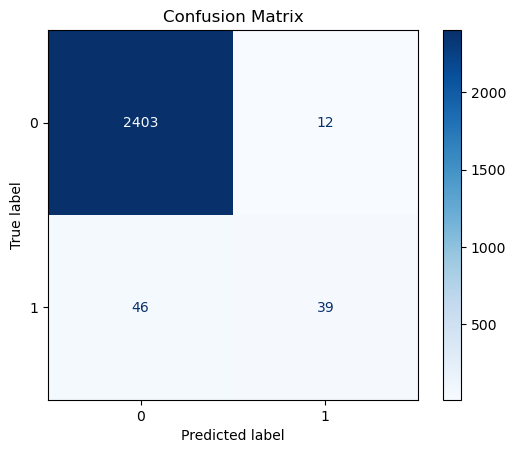

In [180]:
#Confusion Matrix - On Original Dataset using XGBoost Model
from sklearn.metrics import ConfusionMatrixDisplay

#ConfusionMatrixDisplay.from_estimator(random_xgb_org.best_estimator_, x_test_scaled_org, y_test)
#plt.show()

ConfusionMatrixDisplay.from_estimator(
    random_xgb_org.best_estimator_,
    x_test_scaled_org,
    y_test,
    cmap='Blues' 
)

plt.title("Confusion Matrix")
plt.show()

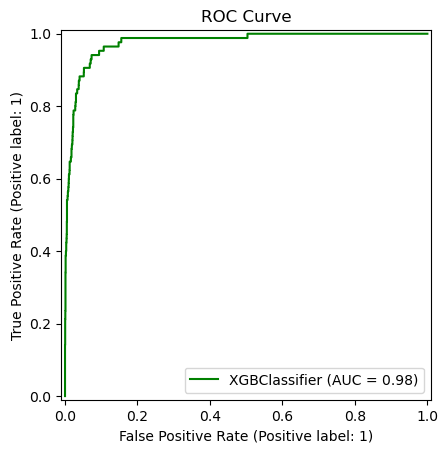

In [179]:
#ROC Curve - Original Dataset on XGBoost Model
from sklearn.metrics import RocCurveDisplay

#RocCurveDisplay.from_estimator(random_xgb_org.best_estimator_, x_test_scaled_org, y_test)
#plt.show()

RocCurveDisplay.from_estimator(
    random_xgb_org.best_estimator_,
    x_test_scaled_org,
    y_test,
    curve_kwargs={"color": "Green"}
)

plt.title("ROC Curve")
plt.show()


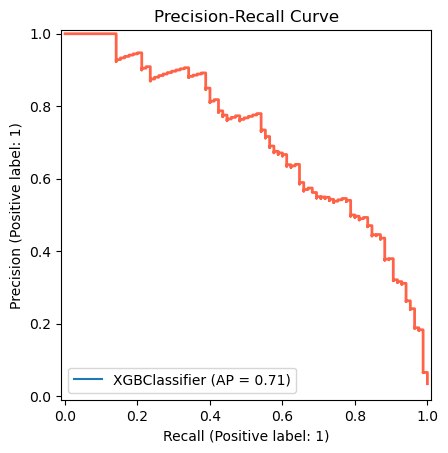

In [172]:
#Precision–Recall Curve

from sklearn.metrics import PrecisionRecallDisplay

#PrecisionRecallDisplay.from_estimator(random_xgb_org.best_estimator_, x_test_scaled_org, y_test)
#plt.show()
#Note: curve_kwargs → not supported in your sklearn version. Hence, ax.lines[0] is used

fig, ax = plt.subplots()

PrecisionRecallDisplay.from_estimator(
    random_xgb_org.best_estimator_,
    x_test_scaled_org,
    y_test,
    ax=ax
)

# change line color AFTER plotting
ax.lines[0].set_color("tomato")
ax.lines[0].set_linewidth(2)

ax.set_title("Precision-Recall Curve")

plt.show()

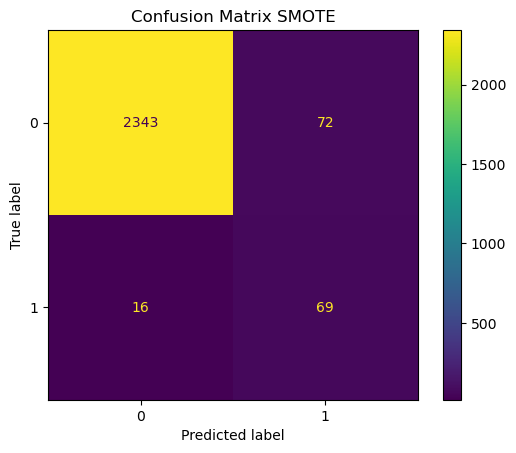

In [174]:
#Confusion Matrix - For XGBoost model on SMOTE dataset

XGBoost_Smote = XGBClassifier(random_state=3, eval_metric="logloss");
XGBoost_Smote.fit(x_smote_train_scaled, y_train_smote)

ConfusionMatrixDisplay.from_estimator(
    XGBoost_Smote,
    x_smote_test_scaled,
    y_test,
    cmap='viridis' 
)

plt.title("Confusion Matrix SMOTE")
plt.show()

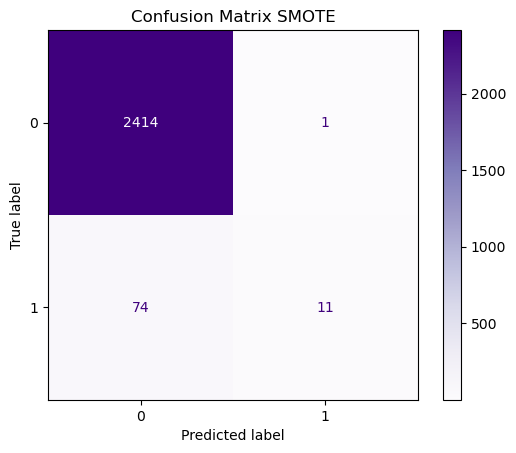

In [175]:
#Confusion Matrix - For Hyperparameter tuned XGBoost model on SMOTE dataset

ConfusionMatrixDisplay.from_estimator(
    random_xgb.best_estimator_,
    x_smote_test_scaled,
    y_test,
    cmap='Purples' 
)

plt.title("Confusion Matrix SMOTE")
plt.show()


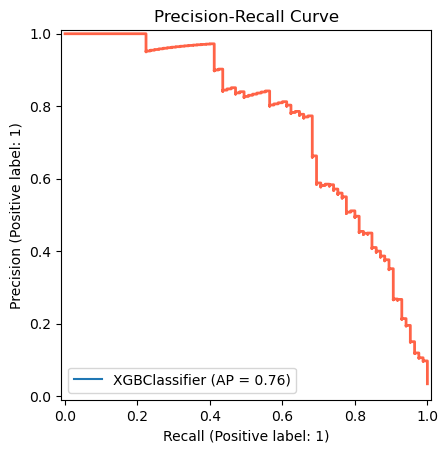

In [176]:
#Precision–Recall Curve - XGBoost Model on SMOTE Dataset

from sklearn.metrics import PrecisionRecallDisplay

#PrecisionRecallDisplay.from_estimator(random_xgb_org.best_estimator_, x_test_scaled_org, y_test)
#plt.show()
#Note: curve_kwargs → not supported in your sklearn version. Hence, ax.lines[0] is used

fig, ax = plt.subplots()

PrecisionRecallDisplay.from_estimator(
    XGBoost_Smote,
    x_smote_test_scaled,
    y_test,
    ax=ax
)

# change line color AFTER plotting
ax.lines[0].set_color("tomato")
ax.lines[0].set_linewidth(2)

ax.set_title("Precision-Recall Curve")

plt.show()

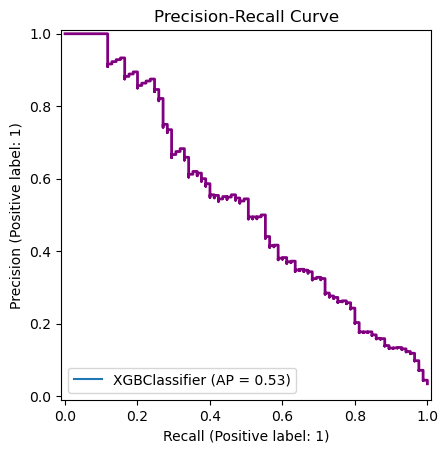

In [177]:
#Precision–Recall Curve - Hyperparameter Tuned XGBoost Model on SMOTE Dataset

from sklearn.metrics import PrecisionRecallDisplay

#PrecisionRecallDisplay.from_estimator(random_xgb_org.best_estimator_, x_test_scaled_org, y_test)
#plt.show()
#Note: curve_kwargs → not supported in your sklearn version. Hence, ax.lines[0] is used

fig, ax = plt.subplots()

PrecisionRecallDisplay.from_estimator(
    random_xgb.best_estimator_,
    x_smote_test_scaled,
    y_test,
    ax=ax
)

# change line color AFTER plotting
ax.lines[0].set_color("purple")
ax.lines[0].set_linewidth(2)

ax.set_title("Precision-Recall Curve")

plt.show()

In [178]:
df_compare_accuracy

,Model Name,Train Accuracy Org,Test Accuracy Org,org_diff,Train Accuracy Smote,Test Accuracy Smote,smote_diff,Train Accuracy Rand,Test Accuracy Rand,rand_diff,Train Accuracy Smote HT,Test Accuracy Smote HT,accuracy gap
0,Logistic Regression,0.9664,0.9668,-0.0004,0.7753,0.7744,0.0009,0.7638,0.7632,0.0006,0.7772,0.7748,0.0024
1,Decision Tree,1.0000,0.9712,0.0288,1.0000,0.9576,0.0424,1.0000,0.8860,0.1140,1.0000,0.9552,0.0448
2,Random Forest,1.0000,0.9792,0.0208,0.9999,0.9608,0.0391,1.0000,0.9028,0.0972,0.9988,0.9576,0.0412
3,KNN,0.9768,0.9740,0.0028,0.9706,0.9252,0.0454,0.8878,0.8576,0.0302,1.0000,0.9308,0.0692
4,SVM,0.9704,0.9704,0.0000,0.9439,0.9128,0.0311,0.8976,0.8680,0.0296,0.9669,0.9420,0.0249
5,Naive Bayes,0.9655,0.9676,-0.0021,0.8405,0.8328,0.0077,0.8425,0.8412,0.0013,0.8405,0.8328,0.0077
6,AdaBoost,0.9695,0.9684,0.0011,0.9078,0.9016,0.0062,0.8898,0.8820,0.0078,0.9155,0.9136,0.0019
7,Bagging,0.9977,0.9796,0.0181,0.9983,0.9596,0.0387,0.9902,0.9088,0.0814,0.7802,0.7816,-0.0014
8,XGBoost,1.0000,0.9800,0.0200,0.9995,0.9648,0.0347,1.0000,0.8976,0.1024,0.9965,0.9652,0.0313


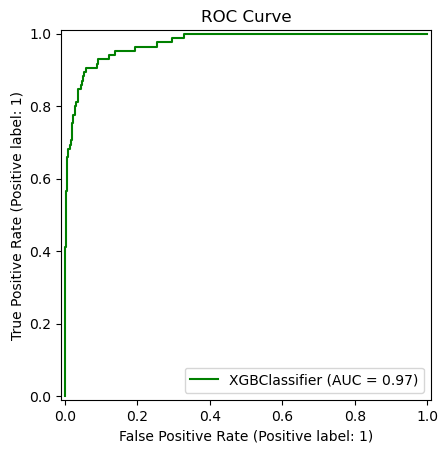

In [181]:
#ROC Curve - SMOTE Dataset on XGBoost Model
from sklearn.metrics import RocCurveDisplay

#RocCurveDisplay.from_estimator(random_xgb_org.best_estimator_, x_test_scaled_org, y_test)
#plt.show()

RocCurveDisplay.from_estimator(
    XGBoost_Smote,
    x_smote_test_scaled,
    y_test,
    curve_kwargs={"color": "Green"}
)

plt.title("ROC Curve")
plt.show()


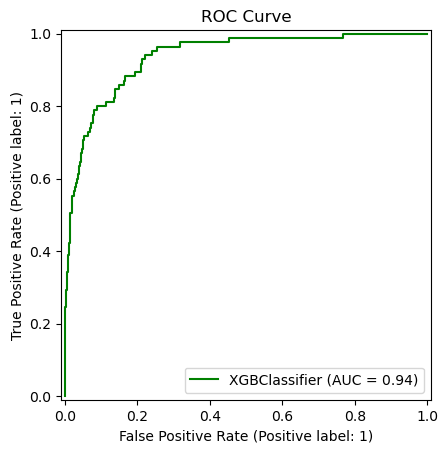

In [182]:
#ROC Curve - SMOTE Dataset on Hyperparameter tuned XGBoost Model
from sklearn.metrics import RocCurveDisplay

#RocCurveDisplay.from_estimator(random_xgb_org.best_estimator_, x_test_scaled_org, y_test)
#plt.show()

RocCurveDisplay.from_estimator(
    random_xgb.best_estimator_,
    x_smote_test_scaled,
    y_test,
    curve_kwargs={"color": "Green"}
)

plt.title("ROC Curve")
plt.show()



Hyperparameter tuned  XGBoost Model using the dataset where class imbalancing has been handled through SMOTE Tomek seems to have least average precision score. Hence, we are rejecting this model.

On paper, Hyperparameter tuned XGBoost Model using the original dataset seems more balanced. It has average precision value of 0.71 and AUC value 0.98 which is comparable to the previous model (XGBoost Model using the dataset where class imbalancing has been handled through SMOTE Tomek). However, there were 46 cases where actual value was failure but predicted value was No Failure.

On the other hand, XGBoost Model using the dataset where class imbalancing has been handled through SMOTE Tomek seems to be most aggressive model.
It has highest average precision value of 0.76 and AUC value 0.97. However, if we observe the confusion matrix, we identify higher cases of false alarms. There are 72 cases where actual value is 0 but predicted value is 1. But, considering preventive maintenance, this is acceptable to me. Hence, proceeding with this model.



#Generating pickle file using the best model of Hyperparameter tuned XGBoost model on Original Dataset
#This model has been rejected due to above reason

pickle.dump(le_type, open("le_predictivemaintenance.pkl", "wb")) #label_encoder
pickle.dump(pt_org, open("powertransformer_predictivemaintenance.pkl", "wb"))  #Power transformer
pickle.dump(scaler_org, open("scaler_predictivemaintenance.pkl", "wb")) #StandardMaxScaler
pickle.dump(random_xgb_org.best_estimator_, open("best_model_predictivemaintenance.pkl", "wb")) #XGBoost Model

In [189]:
#Cross Verifying model performance

models_final = {
    "XGBoost": XGBoost_Smote
}
model_final_acc_df = evaluate_tuned_classification_models(tuned_models = models_final,
    x_training = x_smote_train_scaled,
    y_training= y_train_smote,
    x_testing= x_smote_test_scaled,
    y_testing= y_test,
    overfit_threshold=0.05,
    average='weighted')

In [190]:
model_final_acc_df["diff"] = model_final_acc_df["Train Accuracy"] - model_final_acc_df["Test Accuracy"]

In [191]:
model_final_acc_df

,Model Name,Train Accuracy,Test Accuracy,F1 Score,Overfitting (Y/N),diff
0,XGBoost,0.9995,0.9648,0.969,N,0.0347


In [193]:
#Have keep this commented to prevent accidental clicking. This section must be uncommented.

#Generating pickle file using the best model of Hyperparameter tuned XGBoost model on Original Dataset

import pickle

pickle.dump(le_type, open("le_predictivemaintenance.pkl", "wb")) #label_encoder
pickle.dump(pt, open("powertransformer_predictivemaintenance.pkl", "wb")) 
pickle.dump(scaler, open("scaler_predictivemaintenance.pkl", "wb"))
pickle.dump(XGBoost_Smote, open("best_model_predictivemaintenance.pkl", "wb")) #XGBoost Model

-----------------------------------------------
**Front End Code Below**
------------------------------------------------
------------------------------------------------

**Requirement.txt**

ipykernel

pandas

scikit-learn==1.8.0

streamlit

plotly

matplotlib

seaborn

xgboost

In [ ]:
import streamlit as st
import joblib
import numpy as np
import pickle
import pandas as pd

st.markdown(
    """
    <style>
    .stApp {
        background-color: #90EE90;
        color: brown;   /* default text color */
    }

    h1 {
        color: #1f77b4;  /* blue title */
    }

    label {
        color: #1f77b4 !important;
        font-weight: 600;
    }
    div[data-testid="stRadio"] div[role="radiogroup"] label span p {
        color: brown !important;
        font-weight: 600;
    }
    
    </style>
    """,
    unsafe_allow_html=True
)

le = pickle.load(open("le_predictivemaintenance.pkl", "rb"))   # LabelEncoder
pt = pickle.load(open("powertransformer_predictivemaintenance.pkl", "rb")) #Power Transformer
scaler = pickle.load(open("scaler_predictivemaintenance.pkl", "rb")) #MinMaxScaler
model = pickle.load(open("best_model_predictivemaintenance.pkl", "rb"))  # best XGB model

#st.title("Machine Failure Predictor")
st.markdown(
    "<h1 style='text-align: center;'>Machine Failure Predictor</h1>",
    unsafe_allow_html=True
)
st.image("SS_PREVENTIVE_MAINTENANCE.png", 
             #caption="Income Classifier", 
              use_container_width=True)
st.write("This app predicts the probability of machine failure based on input parameters.")

type_map = {
    "Low": "L",
    "Medium": "M",
    "High": "H"
}

selected = st.radio(
    "Type of Machine",
    options=list(type_map.keys()),
    index=0,
    horizontal=True
)

air_temperature = st.number_input(
    "Air Temperature (K)",
    min_value=273.0,
    max_value=350.0,
    value=300.0,
    step=0.1,
    format="%.1f"
)

process_temperature = st.number_input(
    "Process Temperature (K)",
    min_value=273.0,
    max_value=350.0,    
    value=300.0,
    step=0.1,   
    format="%.1f"
)

rotational_speed = st.number_input(
    "Rotational Speed (RPM)",   
    min_value=0,
    max_value=3000,
    value=1000,
    step=1
)

torque = st.number_input(
    "Torque (Nm)",
    min_value=0.0,
    max_value=100.0,
    value=50.0,
    step=0.1,
    format="%.1f"
)

tool_wear = st.number_input(
    "Tool Wear (min)", 
    min_value=0,
    max_value=300,
    value=100,
    step=1
)


#type = st.radio(
#    "Type of Machine",
#    options=["L", "M", "H"],
#    index=0,
#    horizontal=True
#)



type = type_map[selected]

if st.button("Classify Macine Failure Possibility"):
    input_data = np.array([[type, air_temperature, process_temperature, rotational_speed, torque, tool_wear]])
    input_df = pd.DataFrame(input_data, columns=['type', 'air_temperature', 'process_temperature',
       'rotational_speed', 'torque', 'tool_wear'])
    
    # Encode the categorical variable
    input_df['type'] = le.transform(input_df['type'])

    skewed_cols = ['rotational_speed']
    
    # Apply power transformation
    input_transformed = input_df.copy()
    input_transformed[skewed_cols] = pt.transform(input_df[skewed_cols])
    

    feature_order = ['type', 'air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear']

    input_data = input_transformed[feature_order]
    # Scale the features
    input_scaled = scaler.transform(input_data)
    
    # Make prediction
    prediction = model.predict(input_scaled)
    
    #st.write(f"Prediction: {prediction[0]}")
    if prediction[0] == 1:
        Prediction_text = "High possibility of machine failure."
    else:
        Prediction_text = "Low possibility of machine failure."


#    st.markdown(
#                    f"""
#                    <div style="
#                        background-color:#e8f0ff;
#                        padding:15px;
#                        border-radius:10px;
#                        border:2px solid #0B3D91;
#                        color:#0B3D91;
#                        font-size:18px;
#                        font-weight:bold;
#                        text-align:center;
#                    ">
#                        Predicted Machine Failure Possibility: {Prediction_text}
#                    </div>
#                    """,
#                    unsafe_allow_html=True
#                )


    if Prediction_text == "High possibility of machine failure.":
        bg_color = "#ffebee"      # Light red
        border_color = "#d32f2f"  # Red
        text_color = "#b71c1c"    # Dark red
    else:  # Low possibility of machine failure.
        bg_color = "#e8f0ff"      # Light blue
        border_color = "#0B3D91"  # Blue
        text_color = "#0B3D91"    # Dark blue

    st.markdown(
        f"""
        <div style="
            background-color:{bg_color};
            padding:15px;
            border-radius:10px;
            border:2px solid {border_color};
            color:{text_color};
            font-size:18px;
            font-weight:bold;
            text-align:center;
        ">
            Predicted Machine Failure Possibility: {Prediction_text}
        </div>
        """,
        unsafe_allow_html=True
    )